In [1]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

print("Path to dataset files:", path)

100%|██████████| 653M/653M [03:07<00:00, 3.66MB/s] 

Extracting files...


Path to dataset files: C:\Users\Sibam Das\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13


In [13]:
import os
import pandas as pd

base_path = r"C:\Users\Sibam Das\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13"

file_path = os.path.join(base_path, "US_Accidents_March23.csv")

df = pd.read_csv(file_path)

print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(7728394, 46)


In [15]:
df = df.sample(200000, random_state=42)

In [17]:
columns_needed = [
    "Severity", "Start_Time", "Weather_Condition",
    "Temperature(F)", "Visibility(mi)",
    "Wind_Speed(mph)", "Humidity(%)",
    "Start_Lat", "Start_Lng"
]

df = df[columns_needed]
df = df.dropna()

print("Cleaned Shape:", df.shape)

Cleaned Shape: (183315, 9)


In [21]:
# Convert to datetime safely
df["Start_Time"] = pd.to_datetime(
    df["Start_Time"],
    errors="coerce"
)

# Drop rows where conversion failed
df = df.dropna(subset=["Start_Time"])

# Extract useful features
df["Hour"] = df["Start_Time"].dt.hour
df["Day"] = df["Start_Time"].dt.day_name()
df["Month"] = df["Start_Time"].dt.month

print("Time feature extraction completed.")

Time feature extraction completed.


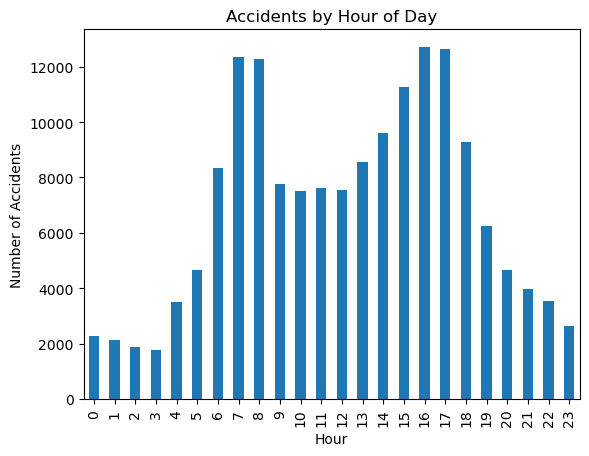

In [23]:
import matplotlib.pyplot as plt

df["Hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

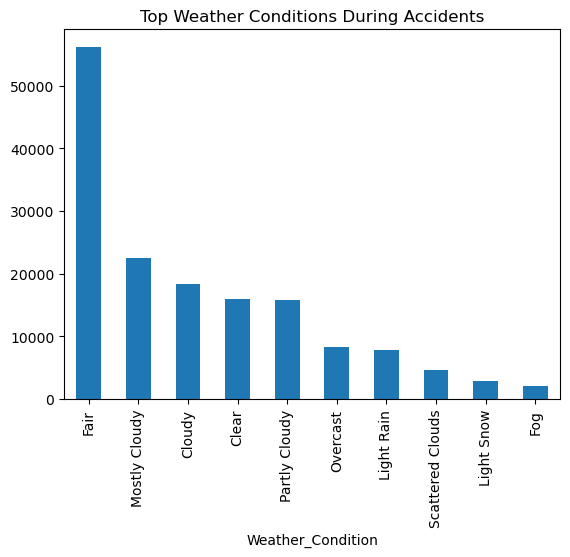

In [25]:
top_weather = df["Weather_Condition"].value_counts().head(10)

top_weather.plot(kind="bar")
plt.title("Top Weather Conditions During Accidents")
plt.show()

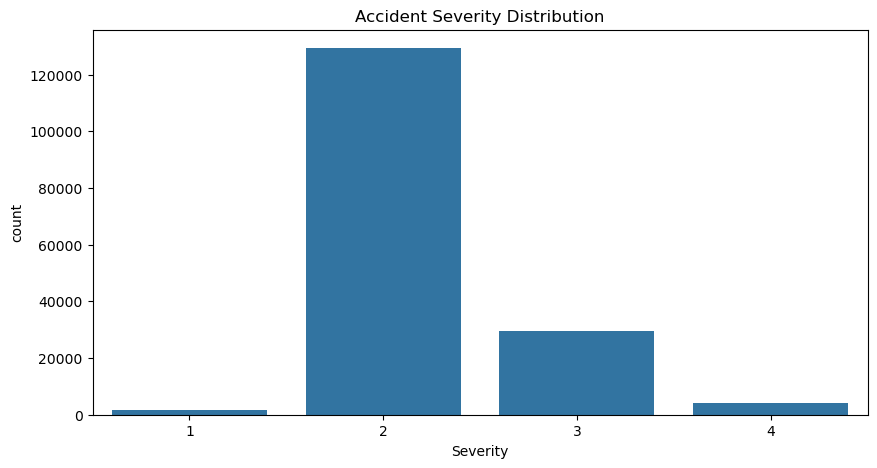

In [27]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Severity")
plt.title("Accident Severity Distribution")
plt.show()

In [29]:
pip install folium

In [31]:
import folium

# Sample smaller data for map
map_data = df.sample(5000)

m = folium.Map(location=[37.09, -95.71], zoom_start=4)

for _, row in map_data.iterrows():
    folium.CircleMarker(
        location=[row["Start_Lat"], row["Start_Lng"]],
        radius=2,
        color="red"
    ).add_to(m)

m

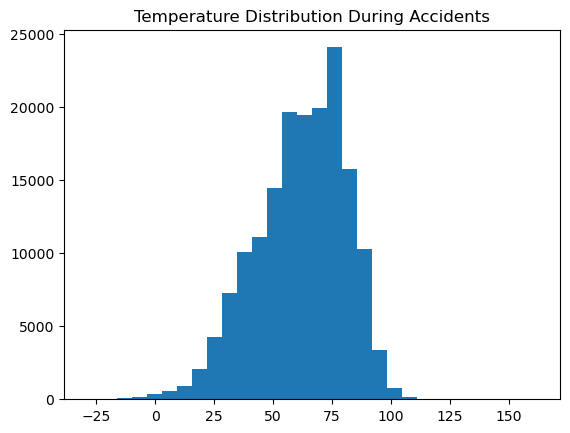

In [33]:
plt.hist(df["Temperature(F)"], bins=30)
plt.title("Temperature Distribution During Accidents")
plt.show()